# Канівське водосховище — стандартизація та імпутація даних

**Метод:** Регресійна імпутація (множинна лінійна регресія)

**Ідея:** Між гідрофізичними та гідрохімічними параметрами води існують фізико-хімічні залежності. Ми використовуємо наявні параметри як предиктори для відновлення пропущених значень методом множинної лінійної регресії (MLR).

**Формули:**
- `N_inorg = NH4 + NO2 + NO3`
- `NP = N_inorg / P_inorg`

## 1. Імпорт бібліотек

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Якщо запущено в Google Colab — завантажити файл вручну
if os.path.exists('/content'):
    from google.colab import files
    uploaded = files.upload()

print('Бібліотеки завантажено')

Бібліотеки завантажено


## 2. Легенда параметрів

In [2]:
LEGEND = pd.DataFrame([
    {'parameter': 'year',      'name_ua': 'Рік відбору проб',                              'unit': '',         'category': 'Метадані'},
    {'parameter': 'month',     'name_ua': 'Місяць відбору проб',                            'unit': '',         'category': 'Метадані'},
    {'parameter': 'date_range','name_ua': 'Проміжок днів відбору проб',                     'unit': '',         'category': 'Метадані'},
    {'parameter': 'station',   'name_ua': 'Станція відбору проб',                           'unit': '',         'category': 'Метадані'},
    {'parameter': 'Chl_a',     'name_ua': 'Хлорофіл а',                                     'unit': 'мкг/дм3', 'category': 'Біомаса фітопланктону'},
    {'parameter': 'Temp',      'name_ua': 'Температура води',                                'unit': '°C',      'category': 'Гідрофізичні'},
    {'parameter': 'DO',        'name_ua': 'Розчинений кисень',                               'unit': 'мг/дм3',  'category': 'Гідрофізичні'},
    {'parameter': 'EC',        'name_ua': 'Електропровідність',                              'unit': 'мкСм/см', 'category': 'Гідрофізичні'},
    {'parameter': 'TDS',       'name_ua': 'Загальна мінералізація',                          'unit': 'мг/дм3',  'category': 'Гідрофізичні'},
    {'parameter': 'pH',        'name_ua': 'Водневий показник',                               'unit': '',         'category': 'Гідрофізичні'},
    {'parameter': 'TSS',       'name_ua': 'Загальний вміст зважених речовин',                'unit': 'мг/дм3',  'category': 'Гідрофізичні'},
    {'parameter': 'NH4',       'name_ua': 'Амонійний азот',                                  'unit': 'мг/дм3',  'category': 'Гідрохімічні'},
    {'parameter': 'NO2',       'name_ua': 'Нітрити',                                         'unit': 'мг/дм3',  'category': 'Гідрохімічні'},
    {'parameter': 'NO3',       'name_ua': 'Нітрати',                                         'unit': 'мг/дм3',  'category': 'Гідрохімічні'},
    {'parameter': 'N_inorg',   'name_ua': 'Загальний неорганічний азот (NH4+NO2+NO3)',       'unit': 'мг/дм3',  'category': 'Гідрохімічні'},
    {'parameter': 'P_inorg',   'name_ua': 'Неорганічний фосфор',                             'unit': 'мг/дм3',  'category': 'Гідрохімічні'},
    {'parameter': 'NP',        'name_ua': 'Співвідношення азоту до фосфору (N_inorg/P_inorg)', 'unit': '',      'category': 'Гідрохімічні'},
])

display(LEGEND)

,parameter,name_ua,unit,category
0,year,Рік відбору проб,,Метадані
1,month,Місяць відбору проб,,Метадані
2,date_range,Проміжок днів відбору проб,,Метадані
3,station,Станція відбору проб,,Метадані
4,Chl_a,Хлорофіл а,мкг/дм3,Біомаса фітопланктону
5,Temp,Температура води,°C,Гідрофізичні
6,DO,Розчинений кисень,мг/дм3,Гідрофізичні
7,EC,Електропровідність,мкСм/см,Гідрофізичні
8,TDS,Загальна мінералізація,мг/дм3,Гідрофізичні
9,pH,Водневий показник,,Гідрофізичні


## 3. Зчитування та стандартизація даних

Оригінальний файл має складну структуру заголовків. Парсимо вручну, розбиваємо дату на компоненти, виправляємо назви станцій.

In [3]:
INPUT_FILE = 'Дані.xlsx'
SHEET_NAME = 'Трав-черв-серп'

# Маппінг українських назв місяців -> номер
MONTH_MAP = {
    'січня': 1, 'лютого': 2, 'березня': 3, 'квітня': 4,
    'травня': 5, 'червня': 6, 'липня': 7, 'серпня': 8,
    'вересня': 9, 'жовтня': 10, 'листопада': 11, 'грудня': 12,
}

def parse_date(raw_date):
    """'22-26 травня 2024' -> (2024, 5, '22-26')"""
    # Нормалізуємо: прибираємо зайві символи (підкреслення тощо)
    s = raw_date.replace('_', ' ').strip()
    m = re.match(r'(\d+(?:-\d+)?)\s+(\S+)\s+(\d{4})', s)
    if not m:
        raise ValueError(f'Не вдалось розпарсити дату: {raw_date!r}')
    date_range = m.group(1)
    month_name = m.group(2).lower()
    year = int(m.group(3))
    month = MONTH_MAP.get(month_name)
    if month is None:
        raise ValueError(f'Невідомий місяць: {month_name!r} у даті {raw_date!r}')
    return year, month, date_range

# Зчитуємо дані
wb = openpyxl.load_workbook(INPUT_FILE)
ws = wb[SHEET_NAME]

rows = []
current_date_raw = None

for row in ws.iter_rows(min_row=3, values_only=True):
    station = row[2]
    if station is None:
        break

    if row[1] is not None:
        current_date_raw = str(row[1]).strip()

    year, month, date_range = parse_date(current_date_raw)

    # Виправляємо назви станцій: S5' -> S5
    station_clean = str(station).strip().replace("'", '')

    rows.append({
        'year': year, 'month': month, 'date_range': date_range,
        'station':  station_clean,
        'Chl_a': row[3], 'Temp': row[4], 'DO': row[5],
        'EC': row[6], 'TDS': row[7], 'pH': row[8], 'TSS': row[9],
        'NH4': row[10], 'NO2': row[11], 'NO3': row[12],
        'N_inorg': row[13], 'P_inorg': row[14], 'NP': row[15],
    })

COLUMNS = LEGEND['parameter'].tolist()
df = pd.DataFrame(rows, columns=COLUMNS)

# Числові колонки
numeric_cols = COLUMNS[4:]  # все після station
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

print(f'Зчитано {len(df)} спостережень з аркуша «{SHEET_NAME}»')
print(f'Роки: {sorted(df["year"].unique())}')
print(f'Місяці: {sorted(df["month"].unique())}')
print(f'Станції: {sorted(df["station"].unique())}')
print(f'\nПропуски по колонках:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Пропусків немає')
display(df)

Зчитано 24 спостережень з аркуша «Трав-черв-серп»
Роки: [np.int64(2021), np.int64(2022), np.int64(2024), np.int64(2025)]
Місяці: [np.int64(5), np.int64(6), np.int64(8)]
Станції: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6']

Пропуски по колонках:
TSS        1
NH4        3
NO2        3
NO3        3
N_inorg    3
P_inorg    3
NP         3
dtype: int64


,year,month,date_range,station,Chl_a,Temp,DO,EC,TDS,pH,TSS,NH4,NO2,NO3,N_inorg,P_inorg,NP
0,2024,5,22-26,S1,5.90,20.9,5.3,305,153,7.26,23.78,0.340,0.0060,0.162,0.508,0.097,5.24
1,2024,5,22-26,S2,4.14,20.7,6.2,327,164,7.40,15.93,0.227,0.0040,0.137,0.368,0.107,3.44
2,2024,5,22-26,S3,5.76,19.9,6.3,310,150,7.23,32.32,0.310,0.0060,0.150,0.466,0.068,6.85
3,2024,5,22-26,S4,2.84,20.5,5.5,308,155,7.19,24.47,0.230,0.0060,0.137,0.373,0.080,4.66
4,2024,5,22-26,S5,2.52,20.1,6.0,298,143,7.16,27.01,0.340,0.0070,0.156,0.503,0.078,6.45
5,2025,6,11-13,S6,14.11,26.9,8.7,349,173,8.71,12.12,0.100,0.0120,0.250,0.298,0.088,3.39
6,2025,6,11-13,S1,7.97,20.6,5.7,352,174,7.60,7.82,0.130,0.0070,0.149,0.286,0.068,4.21
7,2025,6,11-13,S3,10.87,20.9,6.6,359,170,7.88,6.72,0.125,0.0250,0.173,0.323,0.079,4.09
8,2025,6,11-13,S4,14.88,21.1,5.4,356,177,7.72,20.95,0.163,0.0280,0.213,0.404,0.104,3.88
9,2025,6,11-13,S5,6.48,23.5,7.4,335,164,7.88,2.77,0.135,0.0090,0.110,0.254,0.108,2.35


## 4. Аналіз пропущених значень

Для оцінки структури пропусків побудовано бінарну матрицю (1 — пропуск, 0 — значення присутнє), візуалізовану як теплову карту (heatmap). Це дозволяє виявити закономірності у розташуванні пропусків — зокрема, чи пропуски зосереджені в окремих рядках (спостереженнях) або колонках (параметрах), що є важливим для вибору стратегії імпутації.

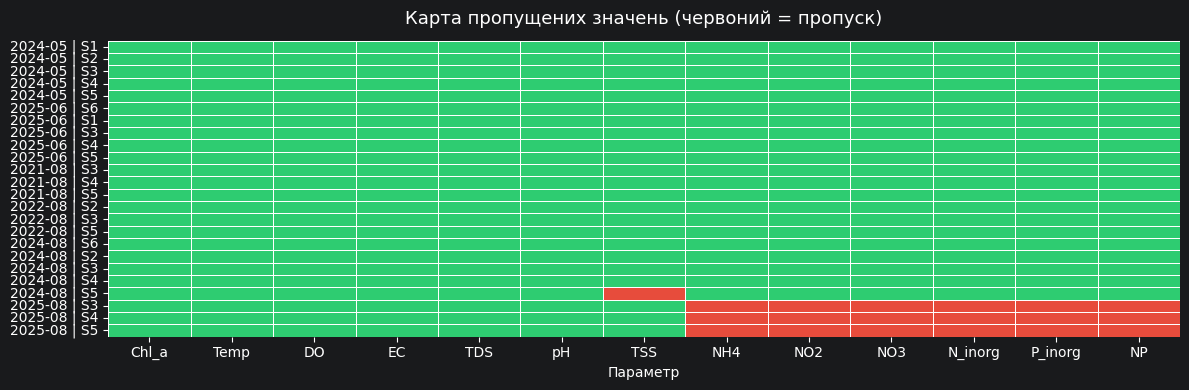

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
missing_matrix = df[numeric_cols].isnull().astype(int)

sns.heatmap(missing_matrix, cmap=['#2ecc71','#e74c3c'], cbar=False,
            yticklabels=[f"{row['year']}-{row['month']:02d} | {row['station']}" for _, row in df.iterrows()],
            ax=ax, linewidths=0.5)
ax.set_title('Карта пропущених значень (червоний = пропуск)', fontsize=13, pad=12)
ax.set_xlabel('Параметр')
plt.tight_layout()
plt.show()

## 5. Кореляційний аналіз

**Метод:** коефіцієнт кореляції Пірсона (Pearson's *r*).

Коефіцієнт Пірсона вимірює лінійну залежність між двома змінними і набуває значень від -1 (повна обернена залежність) до +1 (повна пряма залежність). Аналіз проводиться на повних спостереженнях (без пропусків), щоб уникнути зміщення оцінок.

Результати візуалізуються у вигляді трикутної матриці кореляцій (нижній трикутник), де кольорова шкала відображає напрям та силу зв'язку (зелений — позитивна кореляція, червоний — негативна). На основі цієї матриці обираються предиктори для регресійних моделей імпутації — параметри з найвищими абсолютними значеннями *r* щодо цільової змінної.

Повних рядків для навчання моделей: 20


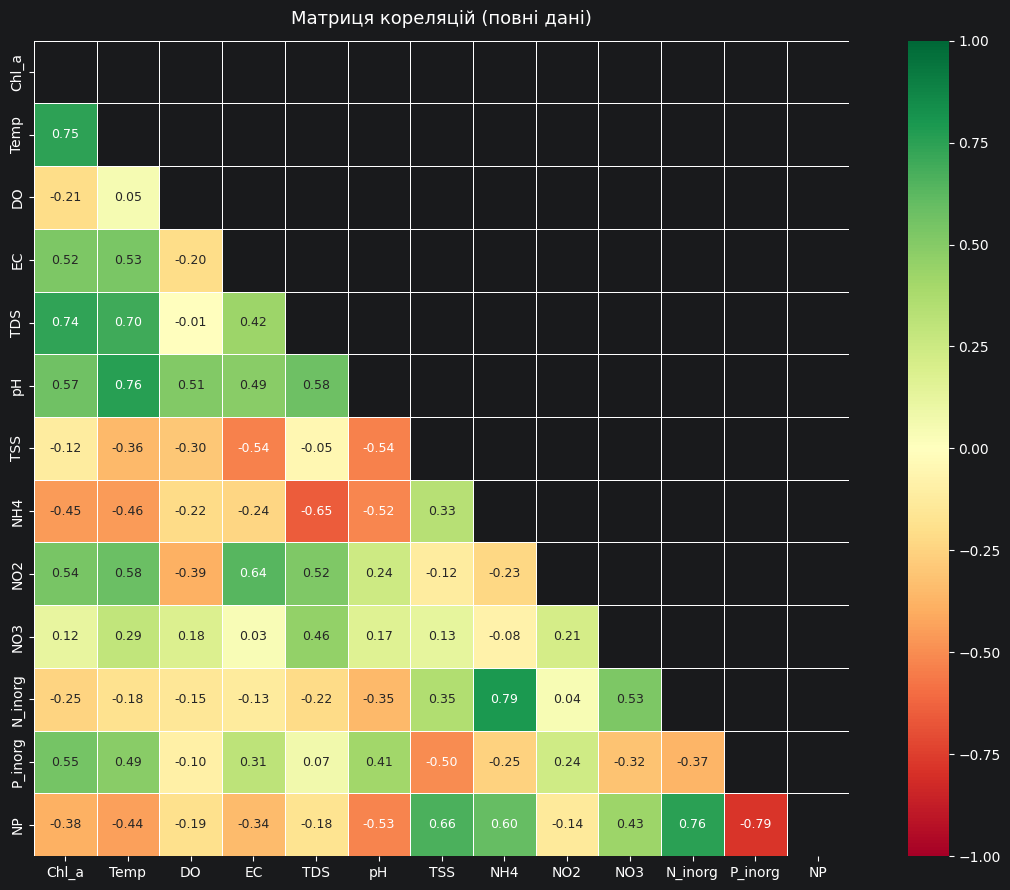

In [5]:
complete = df.dropna()
print(f'Повних рядків для навчання моделей: {len(complete)}')

corr = complete[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Матриця кореляцій (повні дані)', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

## 6. Побудова регресійних моделей

**Метод:** множинна лінійна регресія (Multiple Linear Regression, MLR) за методом найменших квадратів (Ordinary Least Squares, OLS).

Для кожного параметра з пропусками будується окрема регресійна модель виду:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_k x_k$$

де $\hat{y}$ — прогнозоване значення цільового параметра, $x_1, \ldots, x_k$ — предиктори (обрані на основі кореляційного аналізу), $\beta_0, \ldots, \beta_k$ — коефіцієнти, оцінені методом найменших квадратів.

**Оцінка якості моделей:**
- **R² (коефіцієнт детермінації)** — частка дисперсії цільової змінної, пояснена моделлю. Значення від 0 до 1; чим ближче до 1, тим краще модель описує дані.
- **MAE (середня абсолютна похибка)** — середнє абсолютне відхилення прогнозу від факту, в одиницях вимірюваного параметра.

Модель навчається на повних спостереженнях (listwise deletion), після чого використовується для прогнозування пропущених значень.

In [6]:
regression_config = {
    'TSS':     ['pH', 'EC'],
    'NH4':     ['TDS', 'Chl_a', 'Temp'],
    'NO2':     ['EC', 'Temp', 'Chl_a'],
    'NO3':     ['TDS', 'Temp'],
    'P_inorg': ['Chl_a', 'Temp', 'TSS'],
}

models = {}
print(f'{"Параметр":<10} {"Предиктори":<35} {"R²":>6} {"MAE":>8}')
print('-' * 65)

for target, predictors in regression_config.items():
    train = complete[predictors + [target]].dropna()
    X = train[predictors].values
    y = train[target].values
    
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    
    models[target] = {'model': model, 'predictors': predictors, 'r2': r2, 'mae': mae}
    print(f'{target:<10} {str(predictors):<35} {r2:>6.3f} {mae:>8.4f}')

# Вивід отриманих регресійних рівнянь
print('\n' + '=' * 65)
print('ОТРИМАНІ РЕГРЕСІЙНІ МОДЕЛІ:')
print('=' * 65)
for target, info in models.items():
    m = info['model']
    terms = [f'{m.intercept_:+.4f}']
    for coef, name in zip(m.coef_, info['predictors']):
        terms.append(f'{coef:+.4f} * {name}')
    equation = ' '.join(terms)
    print(f'\n{target} = {equation}')
    print(f'  R² = {info["r2"]:.3f}, MAE = {info["mae"]:.4f}')

Параметр   Предиктори                              R²      MAE
-----------------------------------------------------------------
TSS        ['pH', 'EC']                         0.389   5.0111
NH4        ['TDS', 'Chl_a', 'Temp']             0.424   0.0633
NO2        ['EC', 'Temp', 'Chl_a']              0.496   0.0065
NO3        ['TDS', 'Temp']                      0.212   0.0518
P_inorg    ['Chl_a', 'Temp', 'TSS']             0.499   0.0400

ОТРИМАНІ РЕГРЕСІЙНІ МОДЕЛІ:

TSS = +103.6318 -5.5521 * pH -0.1290 * EC
  R² = 0.389, MAE = 5.0111

NH4 = +0.7493 -0.0031 * TDS +0.0004 * Chl_a -0.0015 * Temp
  R² = 0.424, MAE = 0.0633

NO2 = -0.0861 +0.0002 * EC +0.0010 * Temp +0.0001 * Chl_a
  R² = 0.496, MAE = 0.0065

NO3 = -0.0834 +0.0017 * TDS -0.0016 * Temp
  R² = 0.212, MAE = 0.0518

P_inorg = +0.1943 +0.0019 * Chl_a -0.0025 * Temp -0.0038 * TSS
  R² = 0.499, MAE = 0.0400


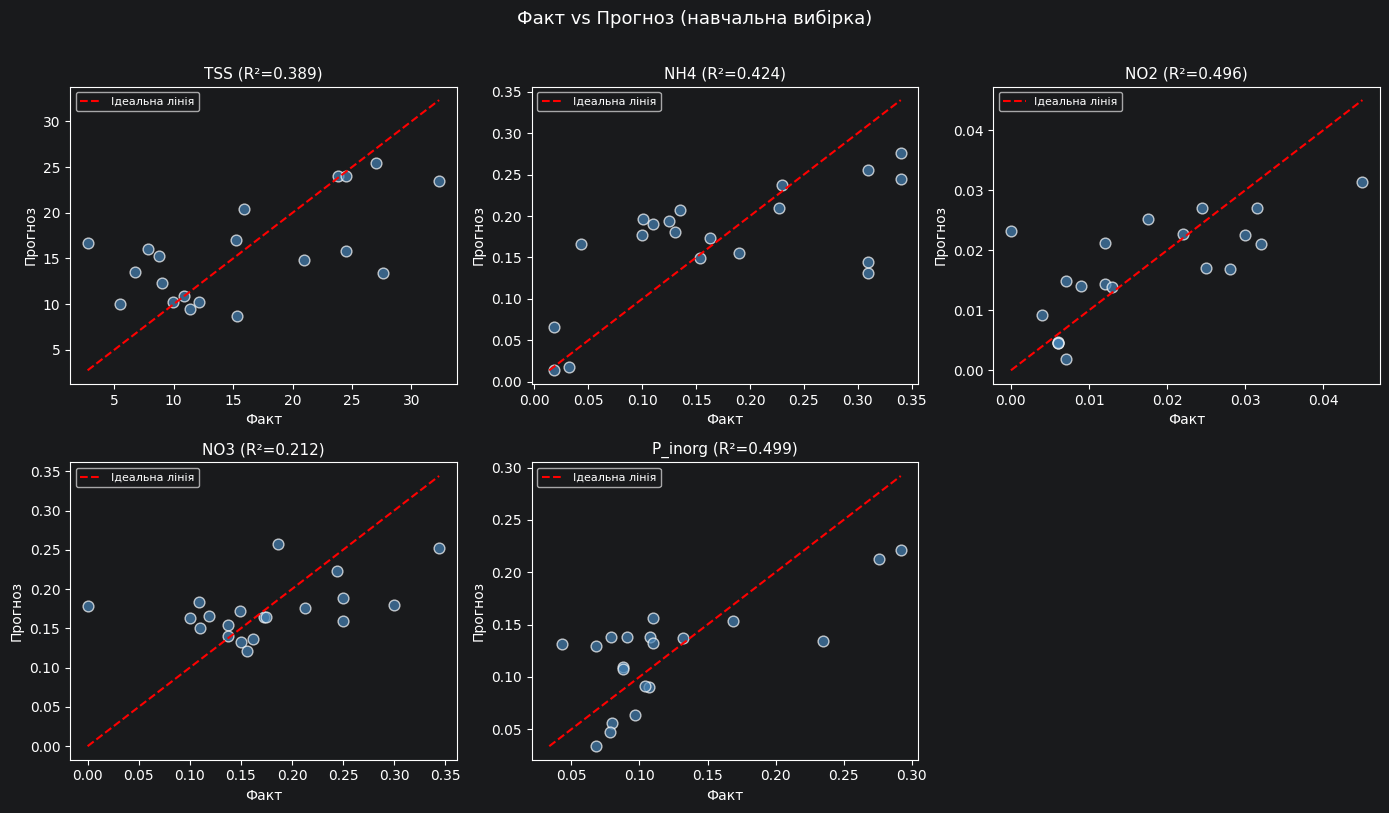

In [7]:
# Графіки: факт vs прогноз для кожної моделі
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (target, info) in enumerate(models.items()):
    train = complete[info['predictors'] + [target]].dropna()
    X = train[info['predictors']].values
    y_true = train[target].values
    y_pred = info['model'].predict(X)
    
    ax = axes[i]
    ax.scatter(y_true, y_pred, color='steelblue', alpha=0.7, edgecolors='white', s=60)
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Ідеальна лінія')
    ax.set_title(f'{target} (R²={info["r2"]:.3f})', fontsize=11)
    ax.set_xlabel('Факт')
    ax.set_ylabel('Прогноз')
    ax.legend(fontsize=8)

axes[-1].axis('off')
fig.suptitle('Факт vs Прогноз (навчальна вибірка)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Заповнення пропущених значень

**Метод:** регресійна імпутація (regression imputation).

Для кожного спостереження з пропусками підставляємо наявні значення предикторів у навчену регресійну модель і отримуємо прогнозоване значення. Від'ємні прогнози обмежуються нулем, оскільки концентрації не можуть бути від'ємними.

Параметри `N_inorg` та `NP` не моделюються регресією, а обчислюються за формулами після заповнення їх складових:
- `N_inorg = NH4 + NO2 + NO3` (сума форм неорганічного азоту)
- `NP = N_inorg / P_inorg` (масове співвідношення азоту до фосфору)

In [8]:
df_filled = df.copy()

missing_idx = df[df.isnull().any(axis=1)].index.tolist()
print('Заповнення пропусків:\n')

for idx in missing_idx:
    row = df_filled.loc[idx]
    print(f'{row["year"]}-{row["month"]:02d} ({row["date_range"]}) | Станція {row["station"]}')
    
    for target, info in models.items():
        if pd.isnull(df_filled.loc[idx, target]):
            predictors = info['predictors']
            if all(pd.notnull(df_filled.loc[idx, p]) for p in predictors):
                X_new = np.array([[df_filled.loc[idx, p] for p in predictors]])
                predicted = info['model'].predict(X_new)[0]
                predicted = max(0, predicted)  # не допускаємо від'ємних концентрацій
                df_filled.loc[idx, target] = round(predicted, 4)
                print(f'  {target} = {predicted:.4f} (предиктори: {predictors})')
    
    # Перерахунок формульних параметрів
    nh4 = df_filled.loc[idx, 'NH4']
    no2 = df_filled.loc[idx, 'NO2']
    no3 = df_filled.loc[idx, 'NO3']
    p_in = df_filled.loc[idx, 'P_inorg']
    if pd.notnull(nh4) and pd.notnull(no2) and pd.notnull(no3):
        n_inorg = nh4 + no2 + no3
        df_filled.loc[idx, 'N_inorg'] = round(n_inorg, 4)
        if pd.notnull(p_in) and p_in > 0:
            df_filled.loc[idx, 'NP'] = round(n_inorg / p_in, 2)

print(f'\nЗалишилось пропусків: {df_filled.isnull().sum().sum()}')

Заповнення пропусків:

2024-08 (12-16) | Станція S5
  TSS = 9.6912 (предиктори: ['pH', 'EC'])
2025-08 (14-16) | Станція S3
  NH4 = 0.1440 (предиктори: ['TDS', 'Chl_a', 'Temp'])
  NO2 = 0.0236 (предиктори: ['EC', 'Temp', 'Chl_a'])
  NO3 = 0.1861 (предиктори: ['TDS', 'Temp'])
  P_inorg = 0.1315 (предиктори: ['Chl_a', 'Temp', 'TSS'])
2025-08 (14-16) | Станція S4
  NH4 = 0.1415 (предиктори: ['TDS', 'Chl_a', 'Temp'])
  NO2 = 0.0256 (предиктори: ['EC', 'Temp', 'Chl_a'])
  NO3 = 0.1835 (предиктори: ['TDS', 'Temp'])
  P_inorg = 0.1403 (предиктори: ['Chl_a', 'Temp', 'TSS'])
2025-08 (14-16) | Станція S5
  NH4 = 0.1843 (предиктори: ['TDS', 'Chl_a', 'Temp'])
  NO2 = 0.0189 (предиктори: ['EC', 'Temp', 'Chl_a'])
  NO3 = 0.1595 (предиктори: ['TDS', 'Temp'])
  P_inorg = 0.1094 (предиктори: ['Chl_a', 'Temp', 'TSS'])

Залишилось пропусків: 0


## 8. Результати

In [9]:
print('=== ПОРІВНЯННЯ: до та після імпутації ===\n')
print('БУЛО (рядки з пропусками):')
display(df.loc[missing_idx])

print('\nСТАЛО (після заповнення):')
def highlight_imputed(val, original):
    return 'background-color: #2E7D32; color: white; font-weight: bold' if pd.isnull(original) else ''

styled = df_filled.loc[missing_idx].style.apply(
    lambda col: [highlight_imputed(v, df.loc[idx, col.name]) 
                 for idx, v in col.items()], axis=0
)
display(styled)

=== ПОРІВНЯННЯ: до та після імпутації ===

БУЛО (рядки з пропусками):


,year,month,date_range,station,Chl_a,Temp,DO,EC,TDS,pH,TSS,NH4,NO2,NO3,N_inorg,P_inorg,NP
20,2024,8,12-16,S5,20.49,25.4,6.2,380,190,8.09,NaN,0.189,0.008,0.289,0.486,0.117,4.15
21,2025,8,14-16,S3,22.22,23.9,6.0,371,186,7.94,12.28,NaN,NaN,NaN,NaN,NaN,NaN
22,2025,8,14-16,S4,22.23,25.6,7.1,372,186,7.14,8.84,NaN,NaN,NaN,NaN,NaN,NaN
23,2025,8,14-16,S5,10.53,25.1,7.3,348,171,8.35,11.38,NaN,NaN,NaN,NaN,NaN,NaN



СТАЛО (після заповнення):


,year,month,date_range,station,Chl_a,Temp,DO,EC,TDS,pH,TSS,NH4,NO2,NO3,N_inorg,P_inorg,NP
20,2024,8,12-16,S5,20.490000,25.400000,6.200000,380,190,8.090000,9.691200,0.189000,0.008000,0.289000,0.486000,0.117000,4.150000
21,2025,8,14-16,S3,22.220000,23.900000,6.000000,371,186,7.940000,12.280000,0.144000,0.023600,0.186100,0.353700,0.131500,2.690000
22,2025,8,14-16,S4,22.230000,25.600000,7.100000,372,186,7.140000,8.840000,0.141500,0.025600,0.183500,0.350600,0.140300,2.500000
23,2025,8,14-16,S5,10.530000,25.100000,7.300000,348,171,8.350000,11.380000,0.184300,0.018900,0.159500,0.362700,0.109400,3.320000


In [10]:
print('=== ФІНАЛЬНА ТАБЛИЦЯ ===')
print(f'Залишилось пропусків: {df_filled.isnull().sum().sum()}')
display(df_filled)

=== ФІНАЛЬНА ТАБЛИЦЯ ===
Залишилось пропусків: 0


,year,month,date_range,station,Chl_a,Temp,DO,EC,TDS,pH,TSS,NH4,NO2,NO3,N_inorg,P_inorg,NP
0,2024,5,22-26,S1,5.90,20.9,5.3,305,153,7.26,23.7800,0.3400,0.0060,0.1620,0.5080,0.0970,5.24
1,2024,5,22-26,S2,4.14,20.7,6.2,327,164,7.40,15.9300,0.2270,0.0040,0.1370,0.3680,0.1070,3.44
2,2024,5,22-26,S3,5.76,19.9,6.3,310,150,7.23,32.3200,0.3100,0.0060,0.1500,0.4660,0.0680,6.85
3,2024,5,22-26,S4,2.84,20.5,5.5,308,155,7.19,24.4700,0.2300,0.0060,0.1370,0.3730,0.0800,4.66
4,2024,5,22-26,S5,2.52,20.1,6.0,298,143,7.16,27.0100,0.3400,0.0070,0.1560,0.5030,0.0780,6.45
5,2025,6,11-13,S6,14.11,26.9,8.7,349,173,8.71,12.1200,0.1000,0.0120,0.2500,0.2980,0.0880,3.39
6,2025,6,11-13,S1,7.97,20.6,5.7,352,174,7.60,7.8200,0.1300,0.0070,0.1490,0.2860,0.0680,4.21
7,2025,6,11-13,S3,10.87,20.9,6.6,359,170,7.88,6.7200,0.1250,0.0250,0.1730,0.3230,0.0790,4.09
8,2025,6,11-13,S4,14.88,21.1,5.4,356,177,7.72,20.9500,0.1630,0.0280,0.2130,0.4040,0.1040,3.88
9,2025,6,11-13,S5,6.48,23.5,7.4,335,164,7.88,2.7700,0.1350,0.0090,0.1100,0.2540,0.1080,2.35


## 9. Збереження результатів

In [11]:
output_file = 'Дані_заповнено.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df_filled.to_excel(writer, sheet_name='Дані (заповнені)', index=False)
    
    # Імпутовані рядки окремо
    df_imputed_only = df_filled.loc[missing_idx].copy()
    df_imputed_only.insert(0, 'Примітка', 'Імпутовано регресією')
    df_imputed_only.to_excel(writer, sheet_name='Імпутовані рядки', index=False)
    
    # Метрики моделей
    model_metrics = pd.DataFrame([
        {'Параметр': t, 'Предиктори': str(i['predictors']), 
         'R²': round(i['r2'], 4), 'MAE': round(i['mae'], 4)}
        for t, i in models.items()
    ])
    model_metrics.to_excel(writer, sheet_name='Метрики моделей', index=False)
    
    # Легенда
    LEGEND.to_excel(writer, sheet_name='Легенда', index=False)

print(f'Збережено: {output_file}')

Збережено: Дані_заповнено.xlsx


## 10. Візуалізація імпутованих значень

Для наочної оцінки результатів імпутації побудовано точкові діаграми (scatter plots), де оригінальні значення відображені окремо від імпутованих. Це дозволяє візуально оцінити, чи потрапляють відновлені значення в діапазон наявних спостережень і чи не є вони аномальними.

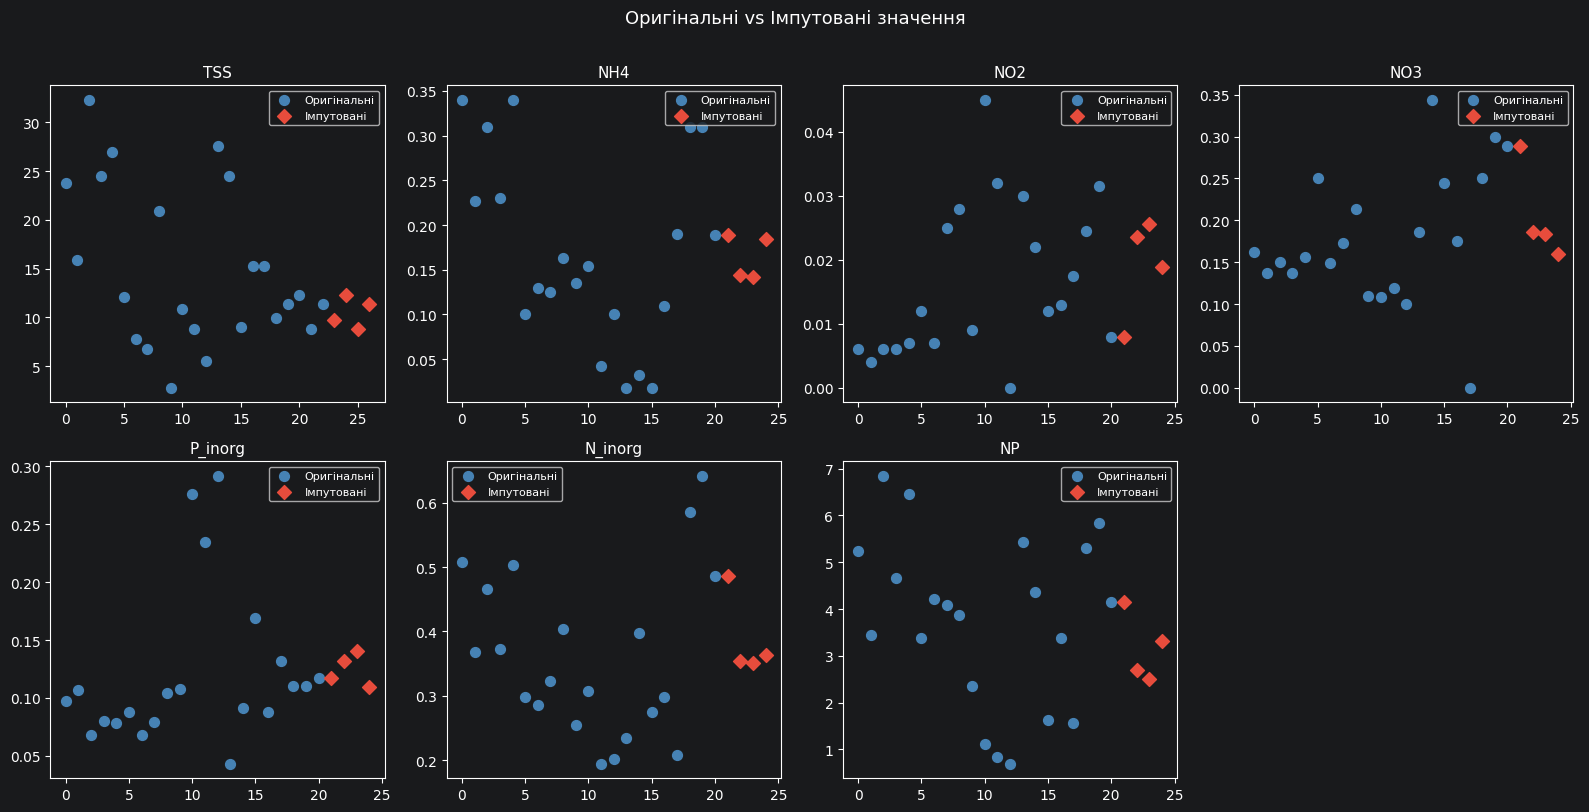

In [12]:
imputed_params = ['TSS', 'NH4', 'NO2', 'NO3', 'P_inorg', 'N_inorg', 'NP']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, param in enumerate(imputed_params):
    ax = axes[i]
    orig_vals = df[param].dropna()
    imp_vals  = df_filled.loc[missing_idx, param]
    
    ax.scatter(range(len(orig_vals)), orig_vals.values, 
               color='steelblue', label='Оригінальні', zorder=3, s=50)
    ax.scatter(range(len(orig_vals), len(orig_vals) + len(imp_vals)), imp_vals.values, 
               color='#e74c3c', label='Імпутовані', zorder=3, s=50, marker='D')
    ax.set_title(param, fontsize=11)
    ax.legend(fontsize=8)

axes[-1].axis('off')
fig.suptitle('Оригінальні vs Імпутовані значення', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Підсумок

| Параметр | Метод | Обґрунтування |
|----------|-------|---------------|
| `TSS` | Множинна регресія (pH, EC) | Найвищі кореляції з TSS |
| `NH4` | Множинна регресія (TDS, Chl_a, Temp) | Біохімічний зв'язок: мінералізація і температура впливають на NH4 |
| `NO2` | Множинна регресія (EC, Temp, Chl_a) | Нітрити корелюють з провідністю і температурою |
| `NO3` | Множинна регресія (TDS, Temp) | Нітрати пов'язані з загальною мінералізацією |
| `P_inorg` | Множинна регресія (Chl_a, Temp, TSS) | Фосфор пов'язаний з фітопланктоном (Chl_a) |
| `N_inorg` | Формула: NH4 + NO2 + NO3 | Точний розрахунок |
| `NP` | Формула: N_inorg / P_inorg | Точний розрахунок |